In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

## 1/4 photon absorption

In [30]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []

    for p in range(num_of_ph_amp):
        
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_base = waveform_zero_fogi[p][n]
            offset=np.mean(y_absorbed)
            offset1=np.mean(y_base)
        
            E = 0
            E1 = 0
    
            for t in range(len(x)):
                t = t 
                E = E + ((y_absorbed[t]-offset)**2)*2
                E1 = E1 + ((y_base[t]-offset1)**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state

In [347]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

In [5]:
header = "D:/K_sunada/result/CDY153/"
#square
data_square="/2024-01-04/2024-01-04T221316_05839672-74_JPA_ab_tr_waveform_qstate"

#time-reversed
data_tr="/2024-01-05/2024-01-05T101531_ebad52db-74_JPA_ab_tr_waveform_qstate"
data_tr1 = "/2024-01-05/2024-01-05T115902_61325f8f-74_JPA_ab_tr_waveform_qstate"
#time-unreersed
data_utr="/2024-01-05/2024-01-05T125508_379d6d27-74_JPA_ab_tr_waveform_qstate"

square

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 1000x1000 with 0 Axes>

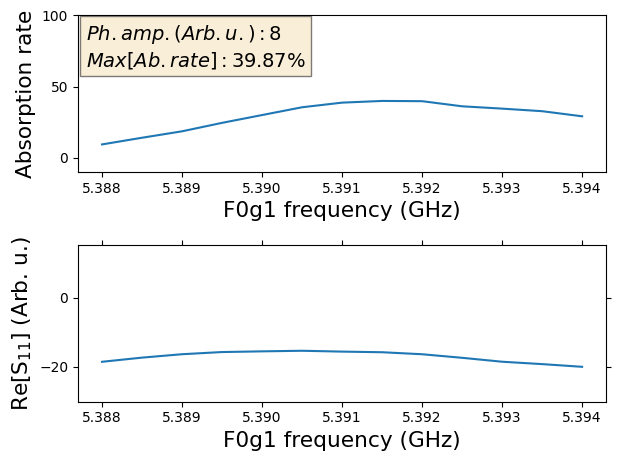

In [6]:
## absorption rate
ph_amp = 8
###############################################
data = data_square
num_of_ph_amp = 9
num_of_fogi_freq = 13
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-10, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, 15)

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Photon number')

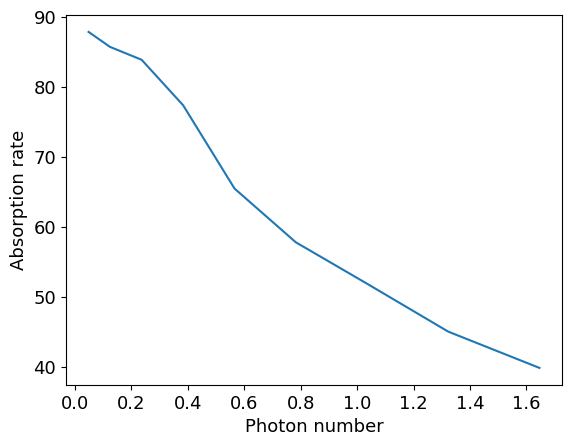

In [7]:
pn_squ = [0.049, 0.125, 0.237, 0.384, 0.566, 0.783, 1.036, 1.323, 1.646]
sq_energy = [2.17e-7, 5.59e-7, 1.06e-6, 1.67e-6, 2.50e-6, 3.45e-6, 4.41e-6, 5.73e-6, 7.47e-6]
sq_rate = [87.85, 85.71, 83.87, 77.37, 65.48, 57.81, 51.88, 45.05, 39.87]
plt.plot(pn_squ, sq_rate)
plt.ylabel("Absorption rate")
plt.xlabel("Photon number")


<Figure size 1000x1000 with 0 Axes>

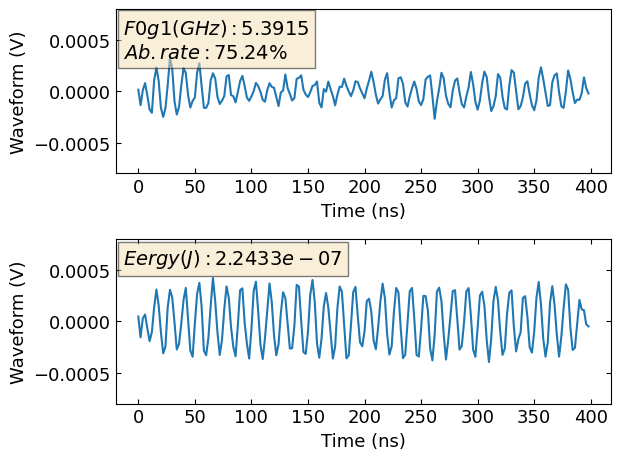

In [242]:
## waveform
ph_amp = 0
fogi_freq = 7
###############################################
data = data_square
num_of_ph_amp = 9
num_of_fogi_freq = 13
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()


time-reverse

<Figure size 1000x1000 with 0 Axes>

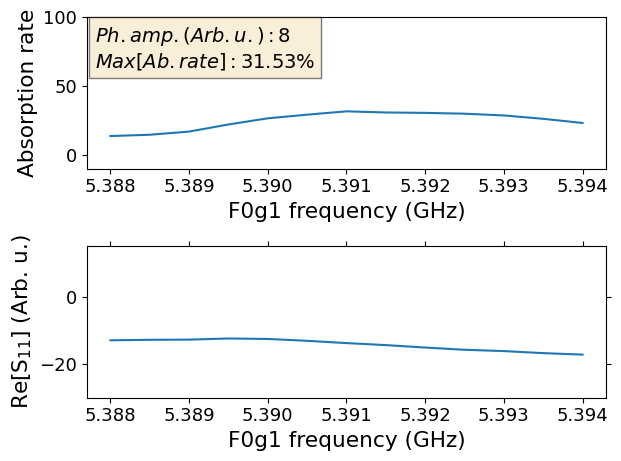

In [9]:
## absorption rate
ph_amp = 8
###############################################
data = data_tr
num_of_ph_amp = 9
num_of_fogi_freq = 13
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-10, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, 15)

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

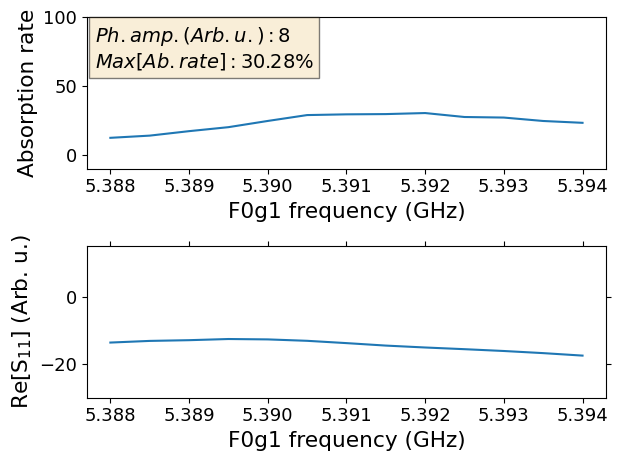

In [10]:
## absorption rate
ph_amp = 8
###############################################
data = data_tr1
num_of_ph_amp = 9
num_of_fogi_freq = 13
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-10, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, 15)

plt.tight_layout()
plt.show()

In [11]:
tr_rate1 = [84.62, 82.52, 74.32, 63.81, 55.67, 48.63, 41.21, 36.56, 30.18]

In [12]:
tr_rate = [83.65, 82.66, 75.78, 69.17, 57.56, 47.78, 42.05, 36.91, 31.53]
tr_energy = [1.33e-7, 3.66e-7, 7.02e-7, 1.21e-6, 1.92e-6, 2.65e-6, 3.24e-6, 4.50e-6, 5.72e-6]

<Figure size 1000x1000 with 0 Axes>

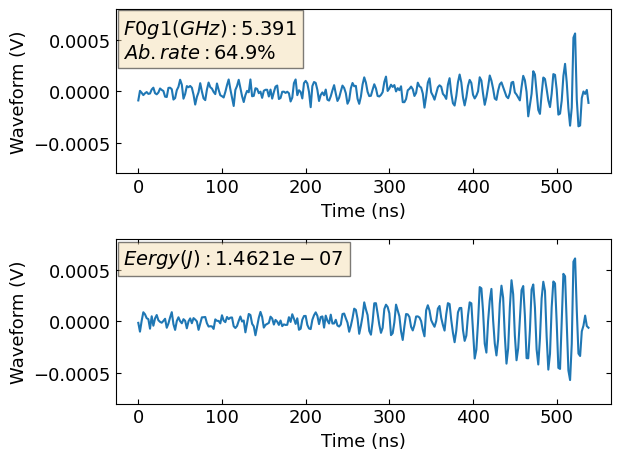

In [241]:
## waveform
ph_amp = 0
fogi_freq = 6
###############################################
data = data_tr
num_of_ph_amp = 9
num_of_fogi_freq = 13
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()


time unreversed

<Figure size 1000x1000 with 0 Axes>

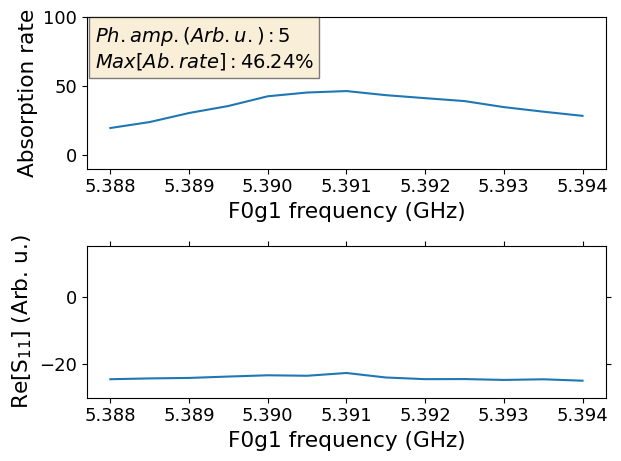

In [14]:
## absorption rate
ph_amp = 5
###############################################
data = data_utr
num_of_ph_amp = 9
num_of_fogi_freq = 13
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-10, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, 15)

plt.tight_layout()
plt.show()

In [15]:
utr_rate = [54.18, 57.61, 62.25, 59.72, 52.83, 46.24, 40.39, 32.83, 28.2]
utr_energy = [2.14e-7, 5.52e-7, 1.07e-6, 1.88e-6, 2.93e-6, 3.87e-6, 5.03e-6, 6.81e-6, 8.76e-6]

<Figure size 1000x1000 with 0 Axes>

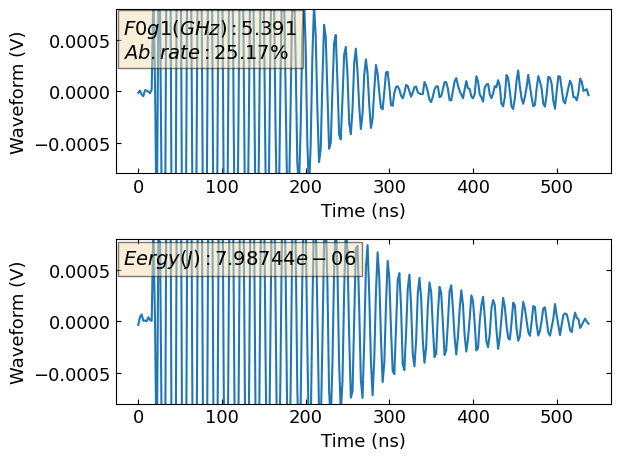

In [243]:
## waveform
ph_amp = 8
fogi_freq = 6
###############################################
data = data_utr
num_of_ph_amp = 9
num_of_fogi_freq = 13
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

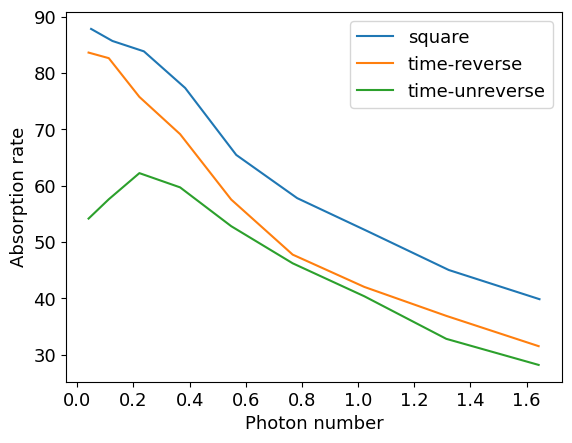

In [17]:
pn_squ = [0.049, 0.125, 0.237, 0.384, 0.566, 0.783, 1.036, 1.323, 1.646]
sq_energy = [2.17e-7, 5.59e-7, 1.06e-6, 1.67e-6, 2.50e-6, 3.45e-6, 4.41e-6, 5.73e-6, 7.47e-6]
sq_rate = [87.85, 85.71, 83.87, 77.37, 65.48, 57.81, 51.88, 45.05, 39.87]

pn_tr = [0.040, 0.112, 0.221, 0.366, 0.548, 0.767, 1.022, 1.314, 1.643]
tr_rate = [83.65, 82.66, 75.78, 69.17, 57.56, 47.78, 42.05, 36.91, 31.53]
tr_energy = [1.33e-7, 3.66e-7, 7.02e-7, 1.21e-6, 1.92e-6, 2.65e-6, 3.24e-6, 4.50e-6, 5.72e-6]

utr_rate = [54.18, 57.61, 62.25, 59.72, 52.83, 46.24, 40.39, 32.83, 28.2]
utr_energy = [2.14e-7, 5.52e-7, 1.07e-6, 1.88e-6, 2.93e-6, 3.87e-6, 5.03e-6, 6.81e-6, 8.76e-6]
plt.xlabel('Photon number')
plt.ylabel('Absorption rate')
plt.plot(pn_squ, sq_rate, label = "square")
plt.plot(pn_tr, tr_rate, label = "time-reverse")
plt.plot(pn_tr, utr_rate, label = "time-unreverse")

plt.legend()

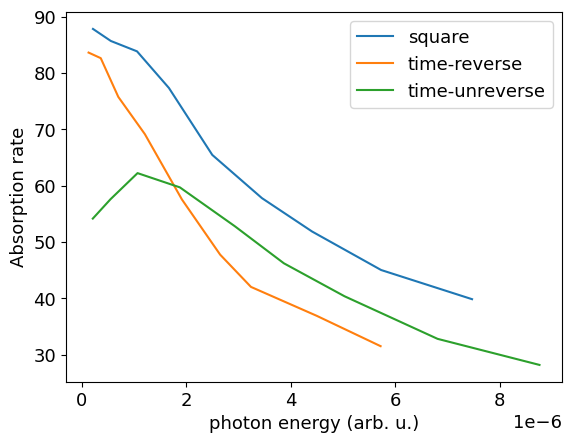

In [18]:
plt.xlabel('photon energy (arb. u.)')
plt.ylabel('Absorption rate')
plt.plot(sq_energy, sq_rate, label = "square")
plt.plot(tr_energy, tr_rate, label = "time-reverse")
plt.plot(utr_energy, utr_rate, label = "time-unreverse")
plt.legend()

## 500ns + delay

In [174]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_delay(header, data, num_of_ph_amp, num_of_fogi_freq):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []

    for p in range(num_of_ph_amp):
        
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_base = waveform_zero_fogi[p][n]
            offset=np.mean(y_absorbed)
            offset1=np.mean(y_base)
        
            E = 0
            E1 = 0
    
            for t in range(len(x)-40):
                t = t +15
                E = E + ((y_absorbed[t]-offset)**2)*2
                E1 = E1 + ((y_base[t]-offset1)**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state

In [443]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

In [403]:
header = "D:/K_sunada/result/CDY153/"
#square
data_square_0106="/2024-01-06/2024-01-06T192217_77ba7412-74_JPA_ab_waveform_qstate"
data_square_17 = "/2024-01-07/2024-01-07T120847_130a0f40-74_JPA_ab_waveform_qstate"
#time-reversed
data_tr_0106="/2024-01-06/2024-01-06T181344_e47dae8d-74_JPA_ab_waveform_qstate"
data_tr_0107="/2024-01-07/2024-01-07T014846_75317617-74_JPA_ab_waveform_qstate"
data_tr_17 = "/2024-01-07/2024-01-07T101307_ea7cb53b-74_JPA_ab_waveform_qstate"

#time-unreersed
data_utr_0106="/2024-01-06/2024-01-06T170603_6f782fbc-74_JPA_ab_waveform_qstate"
data_utr_0107="/2024-01-07/2024-01-07T084830_184d4661-74_JPA_ab_waveform_qstate"
data_utr_17 = "/2024-01-07/2024-01-07T105330_8e7894dd-74_JPA_ab_waveform_qstate"

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 1000x1000 with 0 Axes>

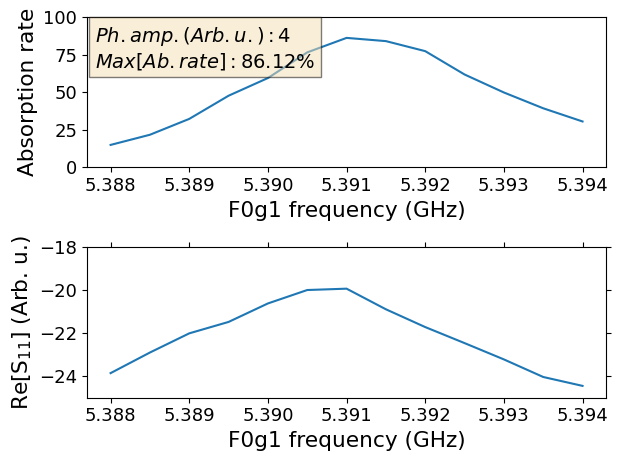

In [404]:
## absorption rate
ph_amp =4
###############################################
data = data_square_17
num_of_ph_amp = 5
num_of_fogi_freq = 13
###############################################
d = data_acquisition_delay(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-25,-18)

plt.tight_layout()
plt.show()

In [315]:
pn_sq_500 = [0.061, 0.137, 0.244, 0.381, 0.548, 0.746, 0.975, 1.23, 1.52]
sq_rate_500 = [87.73, 85.66, 83.33, 76.37, 69.91, 63.67, 55.51, 50.13, 43.31]
sq_rate_0106 = [83.67, 88.15, 88.28, 82.6, 74.98, 67.47, 62.2, 60.21, 54.72]
sq_rate_17 = [83.35, 89.46, 89.49, 87.86, 86.12]

<Figure size 1000x1000 with 0 Axes>

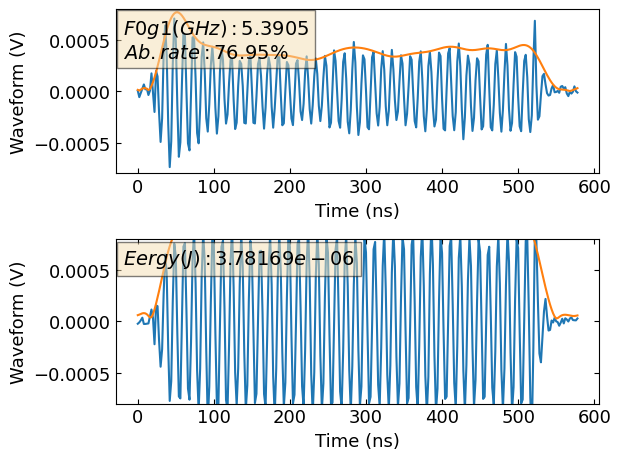

In [465]:
## waveform
ph_amp = 4
fogi_freq = 5
###############################################
data = data_square_17
num_of_ph_amp = 5
num_of_fogi_freq = 13
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 79310344)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

array([-79310344.8275862,  79310344.8275862])

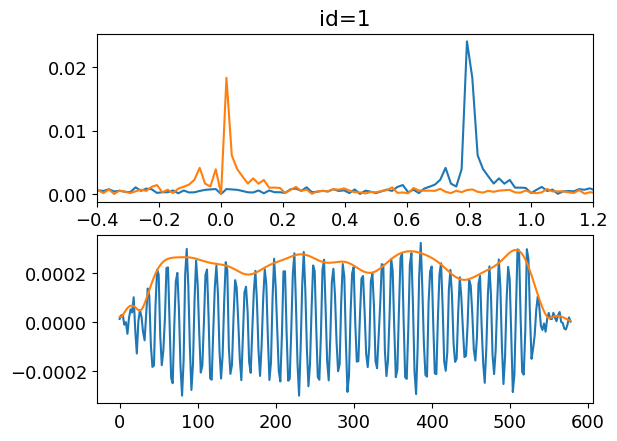

In [457]:
ph_amp = 0
fogi_freq = 6
data = data_square_17
num_of_ph_amp = 5
num_of_fogi_freq = 13

d = data_acquisition_delay(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
x = d[1][ph_amp][fogi_freq]
y = d[3][ph_amp][fogi_freq]
x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]
y_absorbed_shift =  y* np.exp(-1j*2 *np.pi* 79310344*(x*1e-9))
y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
y_fft1 = FFT(x, y_absorbed_shift)[1]

# x_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[0]
# y_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[1]
peak1 = x_fft[signal.argrelmax(y_fft, order=50)]
fig, (ax1, ax2) = plt.subplots(nrows=2)
ax1.set_title("id=1")
ax1.set_xlim(-0.4e8, 1.2e8)
ax1.plot(x_fft, y_fft)
ax1.plot(x_fft, y_fft1)

ax2.plot(x, y)
ax2.plot(x, y_absorbed_LPF)
peak1

<Figure size 1000x1000 with 0 Axes>

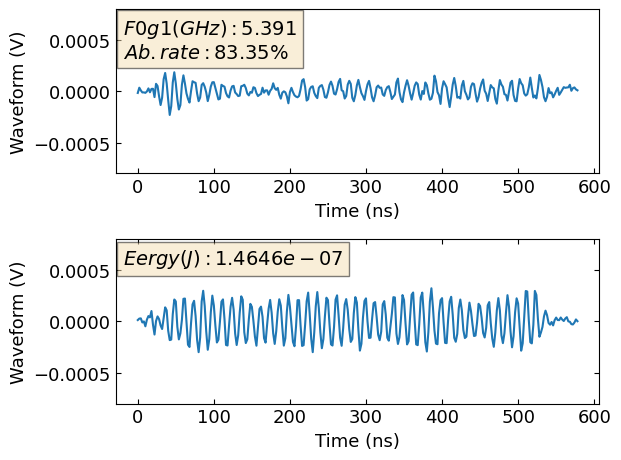

In [458]:
## waveform
ph_amp = 0
fogi_freq = 6
###############################################
data = data_square_17
num_of_ph_amp = 5
num_of_fogi_freq = 13
###############################################
d = data_acquisition_delay(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

array([-79310344.8275862,  79310344.8275862])

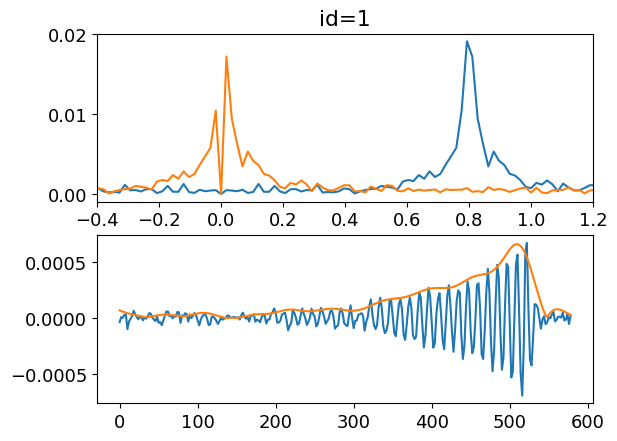

In [445]:
ph_amp = 0
fogi_freq = 6
data = data_tr_17
num_of_ph_amp = 5
num_of_fogi_freq = 13

d = data_acquisition_delay(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
x = d[1][ph_amp][fogi_freq]
y = d[3][ph_amp][fogi_freq]
x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]
y_absorbed_shift =  y* np.exp(-1j*2 *np.pi* 79310344*(x*1e-9))
y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
y_fft1 = FFT(x, y_absorbed_shift)[1]

# x_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[0]
# y_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[1]
peak1 = x_fft[signal.argrelmax(y_fft, order=50)]
fig, (ax1, ax2) = plt.subplots(nrows=2)
ax1.set_title("id=1")
ax1.set_xlim(-0.4e8, 1.2e8)
ax1.plot(x_fft, y_fft)
ax1.plot(x_fft, y_fft1)

ax2.plot(x, y)
ax2.plot(x, y_absorbed_LPF)
peak1

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 1000x1000 with 0 Axes>

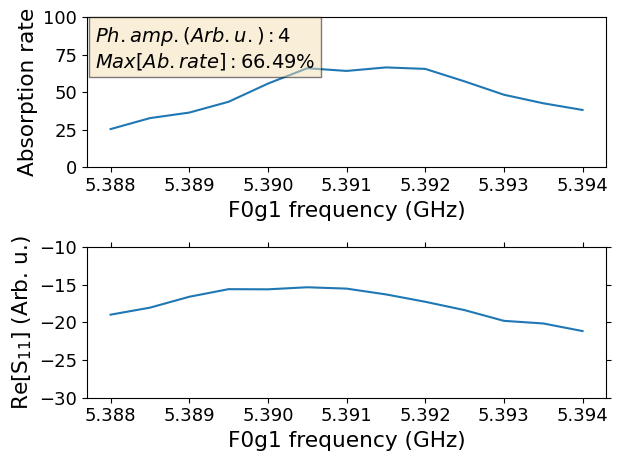

In [452]:
## absorption rate
ph_amp = 4
###############################################
data = data_tr_17
num_of_ph_amp = 5
num_of_fogi_freq = 13
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 79310344)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, -10)

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

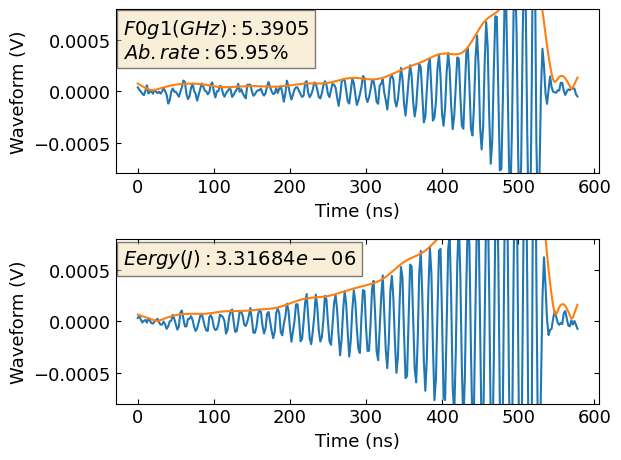

In [456]:
## env energy
ph_amp = 4
fogi_freq = 5
###############################################
data = data_tr_17
num_of_ph_amp = 5
num_of_fogi_freq = 13
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 79310344)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

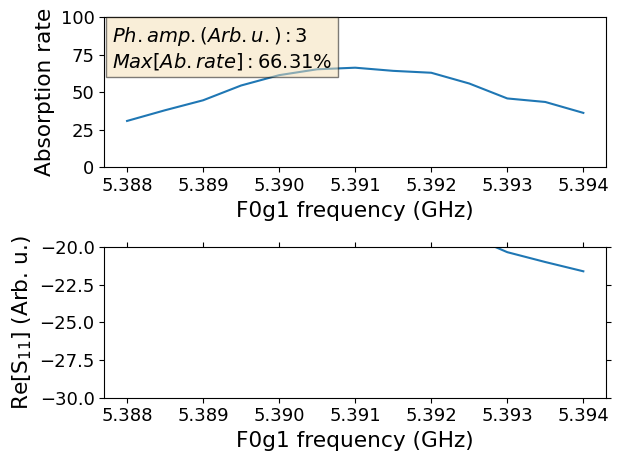

In [346]:
## absorption rate
ph_amp = 3
###############################################
data = data_tr_17
num_of_ph_amp = 5
num_of_fogi_freq = 13
###############################################
d = data_acquisition_delay(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, -20)

plt.tight_layout()
plt.show()

In [305]:
pn_tr_500 = [0.033,0.106,  0.221, 0.378, 0.576, 0.816, 1.10, 1.423, 1.79]
tr_rate_500 = [82.29, 77.93, 69.21, 58.7, 50.47, 41.28, 34.46, 27.94, 24.32]
tr_rate_0106 = [89.17, 86.57, 78.01, 67.81, 54.37, 51.9, 39.91, 34.27, 29.88]
tr_rate_0107 = [90.09, 84.89, 77.38, 64.21, 55.82, 47.81, 38.19, 33.17, 27.99]
tr_rate_17 = [90.74, 86.44, 80.0, 66.31, 64.8]

<Figure size 1000x1000 with 0 Axes>

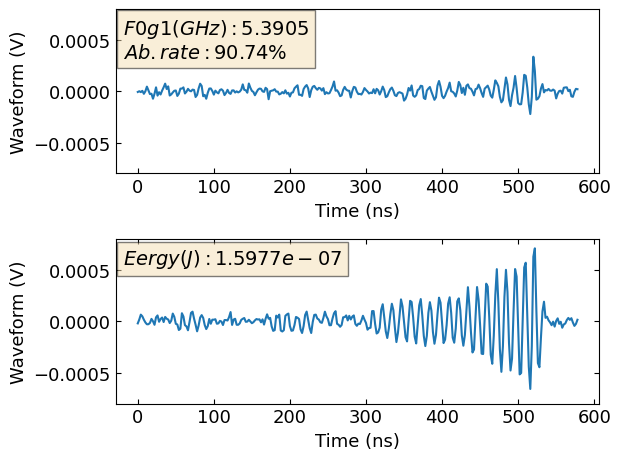

In [330]:
## waveform
ph_amp = 0
fogi_freq = 5
###############################################
data = data_tr_17
num_of_ph_amp = 5
num_of_fogi_freq = 13
###############################################
d = data_acquisition_delay(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

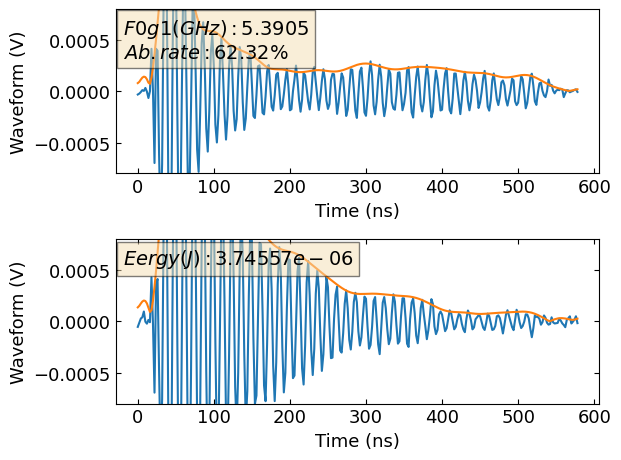

In [470]:
## waveform
ph_amp = 4
fogi_freq = 5
###############################################
data = data_utr_17
num_of_ph_amp = 5
num_of_fogi_freq = 13
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 79310344)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 1000x1000 with 0 Axes>

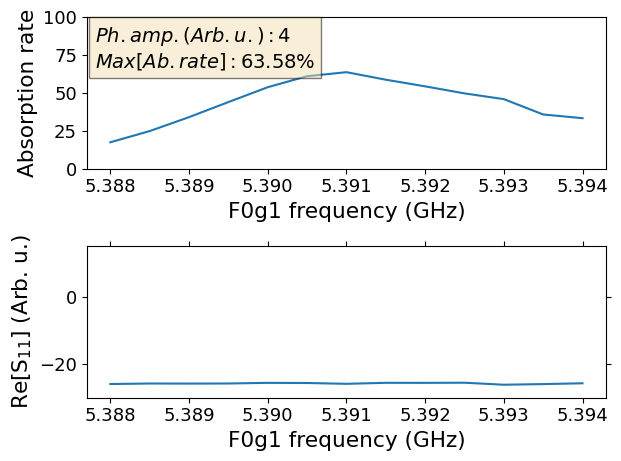

In [300]:
## absorption rate
ph_amp = 4
###############################################
data = data_utr_17
num_of_ph_amp = 5
num_of_fogi_freq = 13
###############################################
d = data_acquisition_delay(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, 15)

plt.tight_layout()
plt.show()

In [301]:
utr_rate_500 = [50.68, 54.92, 55.79, 54.15, 46.96, 40.24, 35.52, 30.17, 25.94]
utr_rate_0106 = [36.03, 44.27, 48.42, 50.14, 51.47, 45.28, 40.03, 35.67, 30.79]
utr_rate_0107 = [45.71, 55.36, 62.2, 62.95, 57.76, 52.14, 44.84, 37.65, 32.79]
utr_rate_17 = [46.22, 54.38, 61.01, 62.95, 63.58]

<Figure size 1000x1000 with 0 Axes>

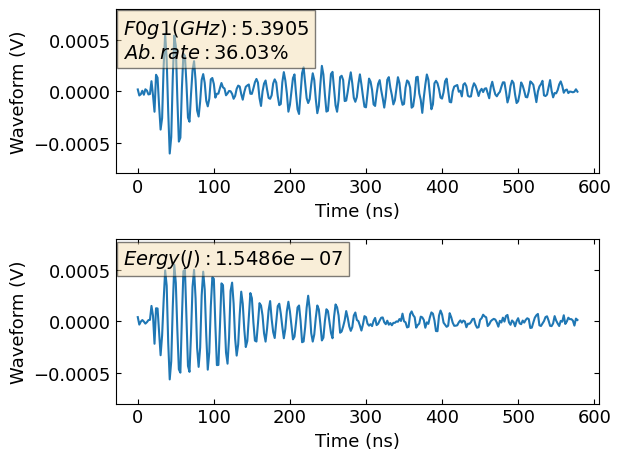

In [236]:
## waveform
ph_amp = 0
fogi_freq = 5
###############################################
data = data_utr_0106
num_of_ph_amp = 9
num_of_fogi_freq = 13
###############################################
d = data_acquisition_delay(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

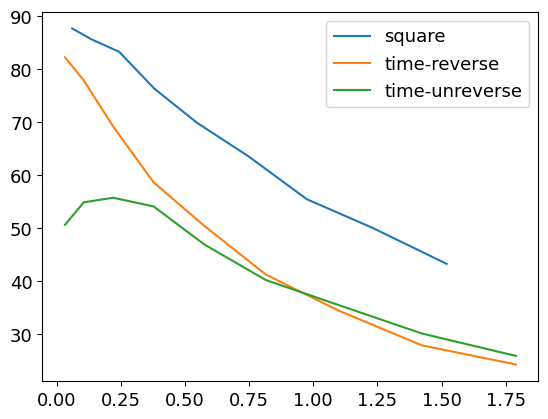

In [283]:
plt.plot(pn_sq_500, sq_rate_500, label = "square")
plt.plot(pn_tr_500, tr_rate_500, label = "time-reverse")
plt.plot(pn_tr_500, utr_rate_500, label = "time-unreverse")
plt.legend()

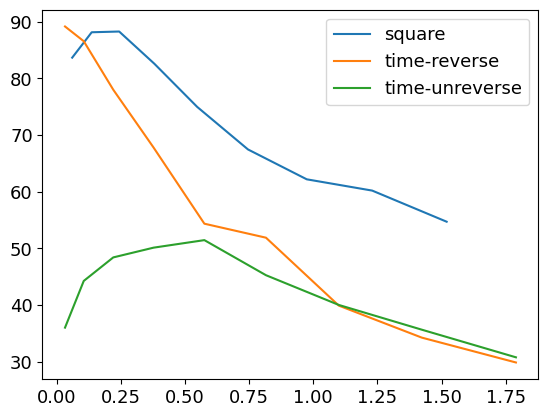

In [233]:
plt.plot(pn_sq_500, sq_rate_0106, label = "square")
plt.plot(pn_tr_500, tr_rate_0106, label = "time-reverse")
plt.plot(pn_tr_500, utr_rate_0106, label = "time-unreverse")
plt.legend()

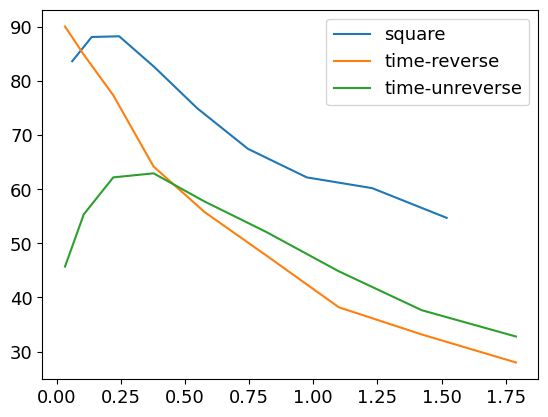

In [302]:
plt.plot(pn_sq_500, sq_rate_0106, label = "square")
plt.plot(pn_tr_500, tr_rate_0107, label = "time-reverse")
plt.plot(pn_tr_500, utr_rate_0107, label = "time-unreverse")
plt.legend()

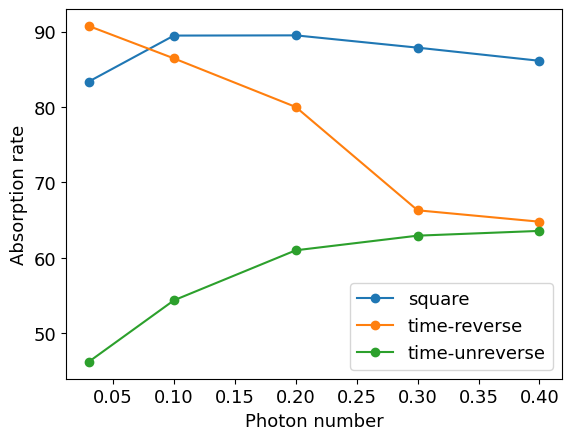

In [474]:
x = [0.03, 0.1, 0.2, 0.3, 0.4]
plt.xlabel("Photon number")
plt.ylabel("Absorption rate")
plt.plot(x, sq_rate_17,'o-', label = 'square')
plt.plot(x, tr_rate_17, 'o-',label = 'time-reverse')
plt.plot(x, utr_rate_17,'o-', label = 'time-unreverse')
plt.legend()

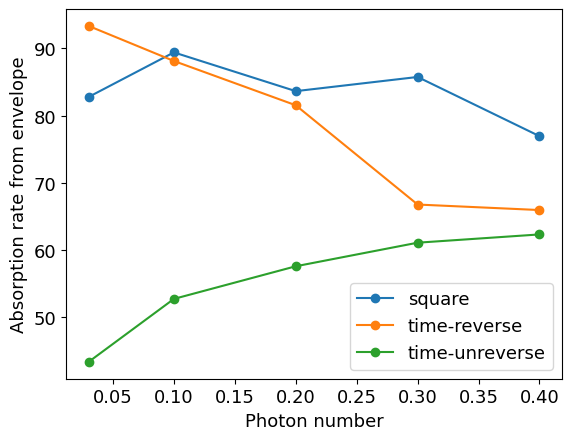

In [475]:
tr_rate_env = [93.36, 88.14, 81.55, 66.77, 65.95]
sq_rate_env = [82.78, 89.42, 83.65, 85.76, 76.95]
utr_rate_env = [43.34, 52.72, 57.58, 61.09, 62.32]
x = [0.03, 0.1, 0.2, 0.3, 0.4]
plt.xlabel("Photon number")
plt.ylabel("Absorption rate from envelope")
plt.plot(x, sq_rate_env, 'o-',label = 'square')
plt.plot(x, tr_rate_env,'o-', label = 'time-reverse')
plt.plot(x, utr_rate_env, 'o-',label = 'time-unreverse')
plt.legend()

Fogi timing

In [250]:
fogi_timing = "/2024-01-07/2024-01-07T002534_d60e3293-75_JPA_ab_fogi_timing"
fogi_timing1 = "/2024-01-07/2024-01-07T011357_985c14d7-75_JPA_ab_fogi_timing"

In [238]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_fogi_timing(header, data, num_of_ph_amp, num_of_fogi_freq):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_delay = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []

    for p in range(num_of_ph_amp):
        
        k = p * num_of_fogi_freq
        d = dd['fogi_delay']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_delay.append(d)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        for n in range(len(fogi_delay[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_base = waveform_zero_fogi[p][n]
            offset=np.mean(y_absorbed)
            offset1=np.mean(y_base)
        
            E = 0
            E1 = 0
    
            for t in range(len(x)-40):
                t = t + 15
                E = E + ((y_absorbed[t]-offset)**2)*2
                E1 = E1 + ((y_base[t]-offset1)**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        
    return fogi_delay, time, waveform, waveform_zero_fogi, energys, rates, q_state

[62.93462453 62.94532462 66.64817968 67.95755726 64.83871339 69.57988967
 71.83263879 71.39481526 68.46371952 73.0952557  70.67604993 72.19973338
 74.20953909 76.08628979 75.58555286 78.29413051 80.62514171 80.04638226
 80.68981802 84.39646134 83.69159116 85.08806821 84.72739901 89.9298658
 88.22610678 87.33673884 89.85385663 90.83831571 90.70214964 91.74530026
 92.49810942 87.70453985 91.03331502 87.61005763 88.4193187  86.80339745
 88.22220323 91.98833337 90.32032236 91.94559101 85.25327918 89.71660699
 90.12359286 90.5287403  88.71713189 87.14995614 88.89591805 91.10561542
 89.57779283 91.41998051 90.1719978  89.35134479 87.96342355 91.7039892
 89.91325405 90.53625959 88.86058372 87.33635855 83.89764097 89.31865893
 90.2512948  89.68384186 90.07580711 89.50574457 89.76134685 88.63752075
 90.57445992 90.59624801 90.14625597 89.60317501 89.77156643 84.84845249
 91.09390119 89.98760175 88.8342945  87.80280064 88.97813602 88.9773933
 89.44886381 86.0586629 ]


<Figure size 1000x1000 with 0 Axes>

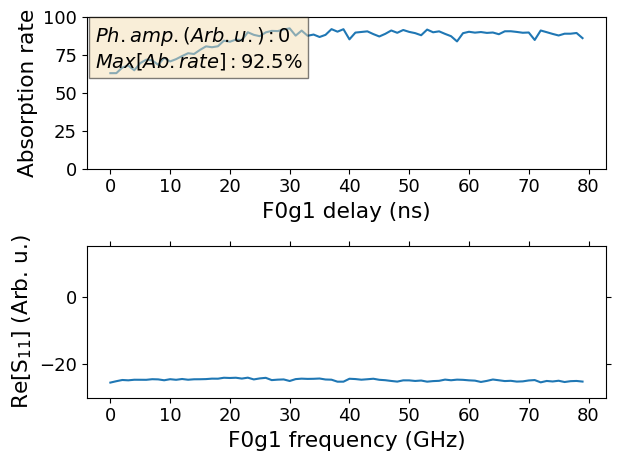

In [249]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing
num_of_ph_amp = 1
num_of_fogi_timing = 81
###############################################
d = data_acquisition_fogi_timing(header, data,num_of_ph_amp, num_of_fogi_timing)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 delay (ns)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
plt.tight_layout()
plt.show()

fogi phase

In [323]:
fogi_phase = "/2024-01-07/2024-01-07T132828_34866729-76_JPA_ab_waveform_qstate_phase"

In [318]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_phase(header, data, num_of_ph_amp, num_of_fogi_freq):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_phase = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []

    for p in range(num_of_ph_amp):
        
        k = p * num_of_fogi_freq
        d = dd['fogi_phase']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_phase.append(d)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        for n in range(len(fogi_phase[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_base = waveform_zero_fogi[p][n]
            offset=np.mean(y_absorbed)
            offset1=np.mean(y_base)
        
            E = 0
            E1 = 0
    
            for t in range(len(x)-40):
                t = t + 15
                E = E + ((y_absorbed[t]-offset)**2)*2
                E1 = E1 + ((y_base[t]-offset1)**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        
    return fogi_phase, time, waveform, waveform_zero_fogi, energys, rates, q_state

[89.03409185 88.22757313 86.74116204 88.78214833 87.30456938 89.14338483
 86.24594073 86.94853445 87.84197236 89.54561605 85.66033245 86.8747463
 86.29165745 85.5537455  90.3176556  82.86630741 87.75815842 84.25972333
 88.03217495 84.20322785 88.52219498]


<Figure size 1000x1000 with 0 Axes>

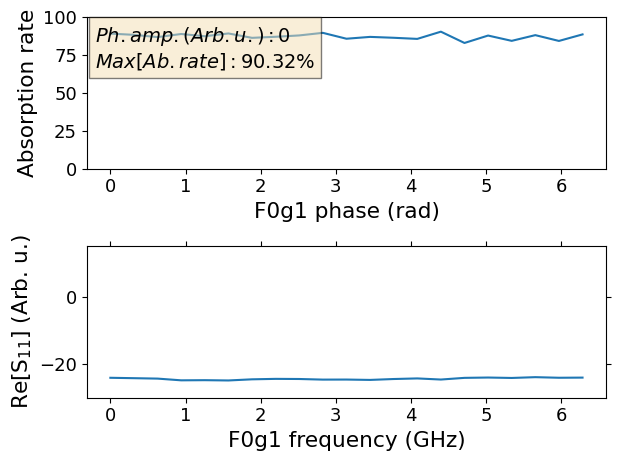

In [324]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_phase
num_of_ph_amp = 1
num_of_fogi_phase = 21
###############################################
d = data_acquisition_phase(header, data,num_of_ph_amp, num_of_fogi_phase)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 phase (rad)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
plt.tight_layout()
plt.show()

ph duration

In [335]:
ph_duration = "/2024-01-09/2024-01-09T105118_94907a60-77_JPA_ab_waveform_qstate_ph_length"

In [336]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_ph_duration(header, data, num_of_ph_amp, num_of_fogi_freq):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    ph_duration = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []

    for p in range(num_of_ph_amp):
        
        k = p * num_of_fogi_freq
        l = dd['ph_length']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        ph_duration.append(l)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        for n in range(len(ph_duration[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_base = waveform_zero_fogi[p][n]
            offset=np.mean(y_absorbed)
            offset1=np.mean(y_base)
        
            E = 0
            E1 = 0
    
            for t in range(len(x)-(90-5*n)):
                t = t + 15
                E = E + ((y_absorbed[t]-offset)**2)*2
                E1 = E1 + ((y_base[t]-offset1)**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        
    return ph_duration, time, waveform, waveform_zero_fogi, energys, rates, q_state

[80.44822527 82.15196901 86.72336232 85.98184772 87.03276428 86.95428306
 87.27858267 87.88725367 79.89403629 84.57254097 85.46348699]


d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 1000x1000 with 0 Axes>

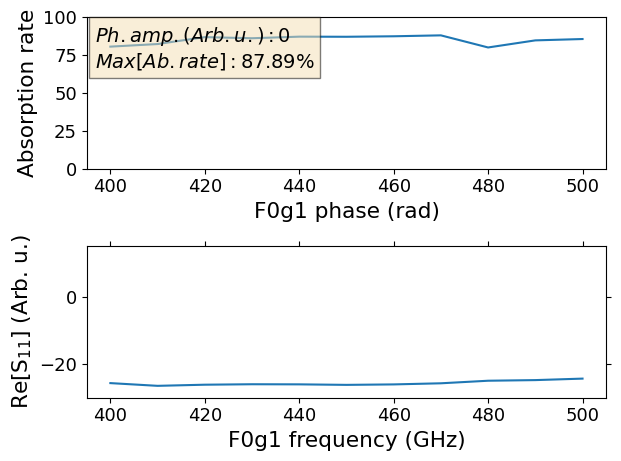

In [337]:
## absorption rate
ph_amp = 0
###############################################
data = ph_duration
num_of_ph_amp = 1
num_of_fogi_phase = 21
###############################################
d = data_acquisition_ph_duration(header, data,num_of_ph_amp, num_of_fogi_phase)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 phase (rad)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
plt.tight_layout()
plt.show()